# **6. A cluster-based analysis for the CR regime**

One way to explore further the differences between CR and EC regimes, is to focus on the statistical dependency between pairs of modes, typically through a representation in a 2D phase space $\vec{\alpha}= (\alpha_j,\alpha_k)$. An adequate sampling frequency $\delta t$ and a large number of records are key to obtain clean results. For the present work, the POD amplitudes $\alpha_k$ are recorded every $\delta t = 0.05$ time units. Additionally, we apply the symmetry operators to the amplitudes α k to increase the number of records. This approach greatly facilitates the interpretation of the phase diagrams by enforcing the natural symmetries of the system.

Phase diagrams provide a convenient way to identify a set stable and unstable fixed points in the 2D subspace (Petschel et al. 2011; Podvin & Sergent 2015; Verma et al. 2015). However, it is quite difficult to extract information connecting the complete set of modes at the same time. To overcome this difficulty, we sought to reduce the dimensionality of the problem further by combining the POD analysis with elements of the Cluster-based reduced-order modelling approach (CROM) introduced by Kaiser et al. (2014).

For this work, the K-means algorithm (see, for instance Jain (2010)) is used as implemented by the scikit-learn Python package (Pedregosa et al. 2011). The K-means algorithm is tasked to find a Voronoi partition such that the squared error between the cluster centroid and the points inside the cluster is minimized over all K clusters.

** This routine concerns figure 12 to 15 and table 5a from section 6 of the article "Conditional statistics of the large-scale reversal dynamics in square Rayleigh–Bénard cells" **

## Preamble

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
pd.set_option('display.max_rows',10)

params = {'backend': 'ps',
          'axes.labelsize': 16,
          'font.size': 16,
          'legend.fontsize': 16,          
          'font.size': 16,          
          'xtick.labelsize': 12,
          'ytick.labelsize': 12,
          'text.usetex': True,
          'font.family': 'serif',
          'figure.figsize': (12, 8),
          'contour.negative_linestyle':'dashed'}
plt.rcParams.update(params)

## 1. Read the time series

In [3]:
filename_modes_pr3   = './data_from_dns/modal_50000000_3_512_016to186.h5'
filename_global_pr3  = './data_from_dns/global_50000000_3_512_016to186.h5'

filename_modes_pr43   = './data_from_dns/modal_50000000_4.3_512_060to259.h5'
filename_global_pr43  = './data_from_dns/global_50000000_4.3_512_060to259.h5'

In [4]:
glb_pr3 = pd.read_hdf(filename_global_pr3)
POD_pr3 = pd.read_hdf(filename_modes_pr3)

POD_pr3['f']=POD_pr3['k1'].abs()
scale_pr3 = POD_pr3.mean()['f']

pod_pr3 = POD_pr3[['k1','k2','k3','k4','k5','k6','f']]/POD_pr3.mean()['f']
pod_pr3['t'] = glb_pr3.t
pod_pr3['CRregime'] = glb_pr3.CRregime

thres_pr3=glb_pr3.mean()['f'] + glb_pr3.std()['f']

del POD_pr3

In [5]:
glb_pr43 = pd.read_hdf(filename_global_pr43)
POD_pr43 = pd.read_hdf(filename_modes_pr43)

POD_pr43['f']=POD_pr43['k1'].abs()
scale_pr43 = POD_pr43.mean()['f']
pod_pr43 = POD_pr43[['k1','k2','k3','k4','k5','k6','f']]/POD_pr43.mean()['f']
pod_pr43['t'] = glb_pr43.t
pod_pr43['k4'] = -pod_pr43.k4
pod_pr43['CRregime'] = glb_pr43.CRregime

thres_pr43=glb_pr43.mean()['f'] + glb_pr43.std()['f']


del POD_pr43

## 2. Cluster partitioning of the 6-D subspace of modal amplitudes
### 2.1 Apply the symmetry operators

In [6]:
cr = pod_pr3.loc[pod_pr3.CRregime==True]
k1 = np.concatenate(( cr.k1.values,-cr.k1.values,-cr.k1.values, cr.k1.values))
k3 = np.concatenate(( cr.k3.values,-cr.k3.values,-cr.k3.values, cr.k3.values))
k2 = np.concatenate(( cr.k2.values, cr.k2.values, cr.k2.values, cr.k2.values))
k5 = np.concatenate(( cr.k5.values, cr.k5.values, cr.k5.values, cr.k5.values))
k4 = np.concatenate(( cr.k4.values,-cr.k4.values, cr.k4.values,-cr.k4.values))
k6 = np.concatenate(( cr.k6.values, cr.k6.values,-cr.k6.values,-cr.k6.values))

alpha_cr_pr3 = np.array([k1,k2,k3,k4,k5,k6])

In [7]:
cr = pod_pr43.loc[pod_pr43.CRregime==True]
k1 = np.concatenate(( cr.k1.values,-cr.k1.values,-cr.k1.values, cr.k1.values))
k3 = np.concatenate(( cr.k4.values,-cr.k4.values,-cr.k4.values, cr.k4.values))
k2 = np.concatenate(( cr.k2.values, cr.k2.values, cr.k2.values, cr.k2.values))
k5 = np.concatenate(( cr.k5.values, cr.k5.values, cr.k5.values, cr.k5.values))
k4 = np.concatenate(( cr.k3.values,-cr.k3.values, cr.k3.values,-cr.k3.values))
k6 = np.concatenate(( cr.k6.values, cr.k6.values,-cr.k6.values,-cr.k6.values))

alpha_cr_pr43 = np.array([k1,k2,k3,k4,k5,k6])

### 2.2 Plot the inertia $J(K)$ as function of K (figure 12)

We use k-means with different values of $K$ and compute the inertia $J(K)$. This is quite expensive to do, so we do it only once and stored the results. 

In [8]:
inertia_cr = pd.read_csv('./results_from_kmeans/inertia_ec.asc',sep='\\s+')
inertia_ec = pd.read_csv('./results_from_kmeans/inertia_ec.asc',sep='\\s+')

inertia_cr=inertia_cr/(np.max(inertia_cr.values))
inertia_ec=inertia_ec/(np.max(inertia_ec.values))

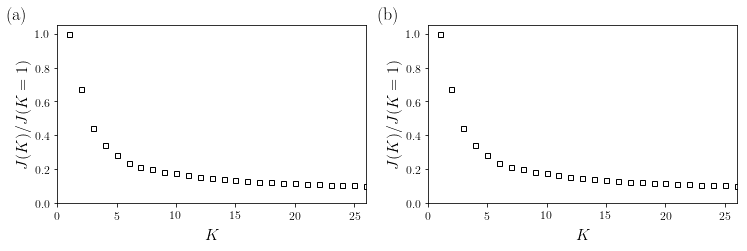

In [10]:
plt.rcParams['figure.figsize'] = (10.5, 3.5)

f, axes = plt.subplots(1,2, sharex=True, sharey=False)
ax= np.ravel(axes)
cmap1 = mpl.cm.RdBu_r

inertia_cr.plot(ax=ax[0], linestyle='None', legend=False, marker='s', color='k', mfc='none', markersize=5)
inertia_ec.plot(ax=ax[1], linestyle='None', legend=False, marker='s', color='k', mfc='none', markersize=5)

for axe in ax:
    axe.set_xlim([0,26])
    axe.set_ylim([0,1.05])
    axe.set_xlabel('$K$')
    axe.set_ylabel('$J(K)/J(K=1)$')

ax[0].annotate('(a)', xy=(0,1), xycoords='axes fraction', xytext=(-50,5), textcoords='offset points', fontsize=18)    
ax[1].annotate('(b)', xy=(0,1), xycoords='axes fraction', xytext=(-50,5), textcoords='offset points', fontsize=18)    


plt.tight_layout(pad=1.5) 
plt.savefig('figures_for_article/figure12.pdf',dpi=300)

### 2.3 Partition the CR subset into $K=12$ clusters
Since this is quite expensive and the resulting clusters are not sorted. Uncomment the lines only if updating the cluster partitioning.

In [14]:
import pickle
from sklearn.cluster import KMeans

n_clusters=12
#kmeans_sym_pr3  = KMeans(init='k-means++', n_clusters=n_clusters, n_init=40, n_jobs=-2).fit(alpha_cr_pr3.T)
#kmeans_sym_pr43 = KMeans(init='k-means++', n_clusters=n_clusters, n_init=40, n_jobs=-2).fit(alpha_cr_pr43.T)

# We save the results as a pickle object
filename_pr3 = './results_from_kmeans/kmeans_symcr_pr3.sav'
#pickle.dump(kmeans_sym_pr3, open(filename_pr3, 'wb'))

filename_pr43 = './results_from_kmeans/kmeans_symcr_pr43.sav'
#pickle.dump(kmeans_sym_pr43, open(filename_pr43, 'wb'))

In [15]:
import pickle
kmeans_sym_pr3  = pickle.load(open(filename_pr3, 'rb'))
kmeans_sym_pr43 = pickle.load(open(filename_pr43, 'rb'))

Sort the centroids using the criteria by Kaiser et al. (2014)

In [16]:
def sort_centroids(unsorted_centroids,n_clusters=12):
    dtype = [('k1', float), ('k4', float)]
    centroids = np.zeros((n_clusters,),dtype=dtype)
    for i in range(0,n_clusters):
        centroids[i]=(unsorted_centroids[i,0],unsorted_centroids[i,3])

    index = np.argsort(centroids,order=['k1','k4'])
    sorted_centroids = unsorted_centroids[index,:]
    return sorted_centroids, index;

def cluster_metrics(n_clusters, cluster, kmeans):   

    cluster_no = range(0,n_clusters)
    probability = pd.DataFrame(columns=['Prob'],index=cluster_no)
    transition  = pd.DataFrame(columns=cluster_no, index=cluster_no)

    for i in cluster_no:
        events = np.where(cluster==i)
        probability.loc[i,'Prob'] = np.size(events)
    
    probability['Prob'] = probability['Prob'].div(probability['Prob'].sum())        
    
    
    for i in cluster_no:
        for j in cluster_no:                
            events = np.where(np.logical_and(cluster[0:-1]==i, cluster[1:]==j))
            transition.loc[j,i] =  np.size(events)
        transition.loc[i,i] = -999999
    
    i=np.argmax(probability['Prob'].values)    
    sorted = [i] 
    for j in range(0,n_clusters-1):    
        next_i=np.nanargmax(transition.loc[i,:].values)
        transition.loc[:,i] = -9999999
        sorted.append(next_i)        
        i = next_i
    
    probability = pd.DataFrame(columns=['Prob'],index=sorted)
    distance    = pd.DataFrame(columns=sorted, index=sorted)
    transition  = pd.DataFrame(columns=sorted, index=sorted)
    
    for i in sorted:
        events = np.where(cluster==i)
        probability.loc[i,'Prob'] = np.size(events)
    
    probability['Prob'] = probability['Prob'].div(probability['Prob'].sum())        
    
    for i in sorted:
        for j in sorted:        
        
            distance.loc[j,i] = np.sqrt(np.dot(
                kmeans.cluster_centers_[j,:] - kmeans.cluster_centers_[i,:],
                kmeans.cluster_centers_[j,:] - kmeans.cluster_centers_[i,:]))
        
            events = np.where(np.logical_and(cluster[0:-1]==j, cluster[1:]==i))
            transition.loc[j,i] =  np.size(events)
    
    distance = distance.fillna(0)
            
    transition = transition.astype(float).div(transition.sum(axis=0), axis=1)
    transition = transition.fillna(0)
    
    probability = probability.reset_index()
    probability = probability.drop(['index'],axis=1)

    transition = transition.reset_index()
    transition = transition.drop(['index'],axis=1)
    transition.columns=range(0,n_clusters)
    
    distance = distance.reset_index()
    distance = distance.drop(['index'],axis=1)
    distance.columns=range(0,n_clusters)
    
    print(" Done sorting! ")
    return probability, transition, distance, sorted

In [17]:
cluster_pr3 = kmeans_sym_pr3.predict(alpha_cr_pr3.T)
probs_pr3 , trans_pr3 , dist_pr3 , sorted_pr3 = cluster_metrics(n_clusters, cluster_pr3,  kmeans_sym_pr3)
centroids_pr3, index_pr3 = sort_centroids(kmeans_sym_pr3.cluster_centers_,n_clusters)


cluster_pr43 = kmeans_sym_pr43.predict(alpha_cr_pr43.T)
probs_pr43 , trans_pr43 , dist_pr43 , sorted_pr43 = cluster_metrics(n_clusters, cluster_pr43,  kmeans_sym_pr43)
centroids_pr43, index_pr43 = sort_centroids(kmeans_sym_pr43.cluster_centers_,n_clusters)

 Done sorting! 
 Done sorting! 


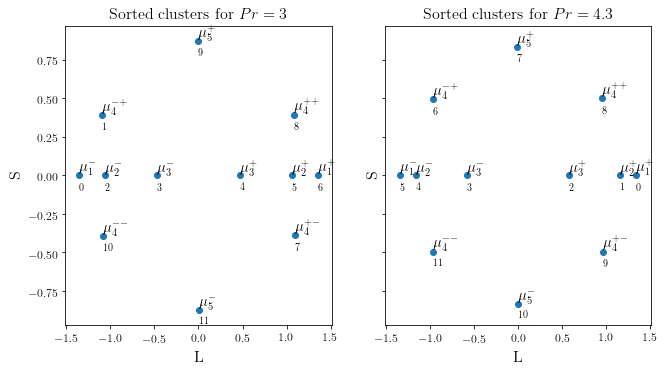

In [18]:
plt.rcParams['figure.figsize'] = (10.5, 5.5)

f, axes = plt.subplots(1, 2, sharey=True, sharex=True)
ax= np.ravel(axes)

ax[0].scatter(kmeans_sym_pr3.cluster_centers_[sorted_pr3[:],0],
              kmeans_sym_pr3.cluster_centers_[sorted_pr3[:],3])

labels = range(n_clusters)

labels_pr3 = ['$\mu_1^{-}$','$\mu_4^{-+}$','$\mu_2^{-}$','$\mu_3^{-}$','$\mu_3^{+}$','$\mu_2^{+}$',
              '$\mu_1^{+}$', '$\mu_4^{+-}$', '$\mu_4^{++}$','$\mu_5^{+}$','$\mu_4^{--}$', '$\mu_5^{-}$']
for i, txt in enumerate(labels):    
    ax[0].annotate(txt, (kmeans_sym_pr3.cluster_centers_[sorted_pr3[i],0],
                         kmeans_sym_pr3.cluster_centers_[sorted_pr3[i],3]), size=10,xytext=(0,-15), textcoords='offset points')
    
for i, txt in enumerate(labels_pr3):    
    ax[0].annotate(txt, (kmeans_sym_pr3.cluster_centers_[sorted_pr3[i],0],
                         kmeans_sym_pr3.cluster_centers_[sorted_pr3[i],3]),size=15)    

    
ax[1].scatter(kmeans_sym_pr43.cluster_centers_[sorted_pr43[:],0],
              kmeans_sym_pr43.cluster_centers_[sorted_pr43[:],3])

labels_pr43 = ['$\mu_1^{+}$','$\mu_2^{+}$','$\mu_3^{+}$','$\mu_3^{-}$','$\mu_2^{-}$','$\mu_1^{-}$',
               '$\mu_4^{-+}$', '$\mu_5^{+}$', '$\mu_4^{++}$','$\mu_4^{+-}$','$\mu_5^{-}$', '$\mu_4^{--}$']
for i, txt in enumerate(labels):        
    ax[1].annotate(txt, (kmeans_sym_pr43.cluster_centers_[sorted_pr43[i],0],
                         kmeans_sym_pr43.cluster_centers_[sorted_pr43[i],3]),size=10,xytext=(0,-15), textcoords='offset points')


for i, txt in enumerate(labels_pr43):        
    ax[1].annotate(txt, (kmeans_sym_pr43.cluster_centers_[sorted_pr43[i],0],
                         kmeans_sym_pr43.cluster_centers_[sorted_pr43[i],3]),size=15)



ax[0].set_title('Sorted clusters for $Pr=3$', size=16)
ax[0].set_xlabel('$\mathrm{L}$')
ax[0].set_ylabel('$\mathrm{S}$')

ax[1].set_title('Sorted clusters for $Pr=4.3$', size=16)
ax[1].set_xlabel('$\mathrm{L}$')
ax[1].set_ylabel('$\mathrm{S}$')

plt.show()

### 2.4 Flow patterns associated to the cluster centroids (figure 13)

In [20]:
import pickle
filename_pr3 = './data_from_pod/pod_modes_pr3_cr.sav'
cr_pr3  = pickle.load(open(filename_pr3, 'rb'))

def input_matrix(file):   
    import struct
    f = open(file, "rb")
    n = struct.unpack("<f", f.read(4))   
    n = np.array(n[0]).astype(int)    
    y = np.zeros((n,))
    x = np.zeros((n,))
    z = np.zeros((n,n))
    for j in range(n):        
        a = struct.unpack("<f", f.read(4))   
        y[j]=a[0]
        
    for i in range(n):
        a = struct.unpack("<f", f.read(4))   
        x[i]=a[0]
        for j in range(n):        
            a = struct.unpack("<f", f.read(4))   
            z[j,i] = a[0]
            
    return x,y,z ;


dir='data_from_pod/modes_pr43_cr'
x,y,_, = input_matrix(dir+'/field-T-000001.bin')

def streamfunction(U,V,n): 
    Delta=1./np.float(n)
    dpsi = np.zeros((n,n))    
    for i in range(1,n-1):   
        for j in range(1,n-1):   
            dpsi[i,j] = 0.5*(U[i+1,j] + U[i,j] - V[i,j+1] - V[i,j])*Delta
    vpsi = np.zeros((n,n))
    for i in range(1,n): 
        for j in range(1,n):           
            vpsi[i,j] = vpsi[i-1,j-1] + dpsi[i,j]          
    return vpsi;

def reconstruct_pr3(a,mode,n_clusters): 
    df = pd.DataFrame(columns=['T','U','V','Psi'])
    for c in np.arange(0,n_clusters):
        T = a[c,0]*mode.loc['T','k1']
        U = a[c,0]*mode.loc['U','k1']
        V = a[c,0]*mode.loc['V','k1']
        i=1
        for k in ['k2','k4','k3','k5','k6']:
            T = T + a[c,i]*mode.loc['T',k]
            U = U + a[c,i]*mode.loc['U',k]
            V = V + a[c,i]*mode.loc['V',k]
            i=i+1
        Psi = streamfunction(U,V,512)
        
        df = df.append({'T':[T],'U':[U],'V':[V],'Psi':[Psi]}, ignore_index=True) 
        
    return df ;

In [21]:
fields_centroids_pr3 = reconstruct_pr3(kmeans_sym_pr3.cluster_centers_[sorted_pr3[:],:], cr_pr3, n_clusters)

/home/andres/.local/lib/python3.6/site-packages/matplotlib/figure.py:2267: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  warnings.warn("This figure includes Axes that are not compatible "


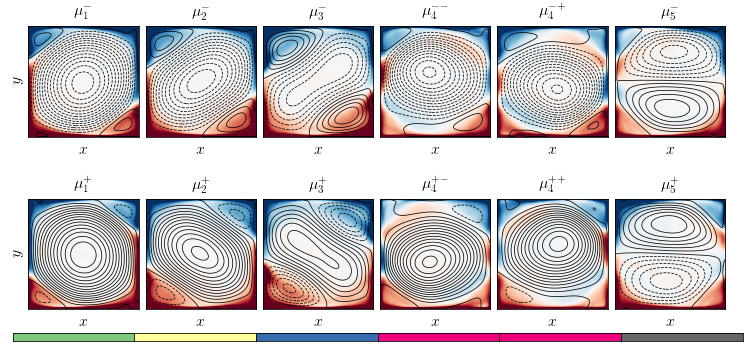

In [22]:
plt.rcParams['figure.figsize'] = (10.5, 4.75)

f, axes = plt.subplots(2,6, sharex=True, sharey=True)
ax= np.ravel(axes)

cmap1 = mpl.cm.RdBu_r
cmap2 = mpl.cm.Accent
norm = mpl.colors.Normalize(vmin=0, vmax=6)

vmin=-0.5; vmax=0.5; i=0
levels=(np.arange(-0.6,0.6,0.04))
for k in [0,2,3,10,1,11, 6,5,4,7,8,9]:
    im=ax[i].imshow(fields_centroids_pr3.loc[k,'T'][0],origin='low', extent=[-0.5, 0.5, -0.5, 0.5], cmap=cmap1, vmin=vmin, vmax=vmax, rasterized=True)
    ax[i].contour(-x,y,fields_centroids_pr3.loc[k,'Psi'][0],levels, colors='k',linewidths=0.75); 
    
    ax[i].set_xlabel('$x$')
    ax[i].set_title(labels_pr3[k],size=16)

    i= i+1
    
ax[0].set_ylabel('$y$')
ax[6].set_ylabel('$y$')
ax[0].set_xlim([-0.5,0.5])
ax[0].set_ylim([-0.5,0.5])
ax[0].set_xticks([])
ax[0].set_yticks([])

cluster_color = [0,2.5,3,4,4,6]
i=0
for axe in ['ax1', 'ax2', 'ax3', 'ax4', 'ax5', 'ax6']:
    axe = f.add_axes([0.03+(0.161)*i, 0.01, 0.161, 0.025])
    axe.set_facecolor(mpl.colors.rgb2hex(cmap2(norm(cluster_color[i]))))
    axe.set_xticks([])
    axe.set_yticks([])
    i=i+1

plt.tight_layout(w_pad=0,h_pad=3.0,rect=[0, 0.03, 1.0, 1.0]) 
plt.savefig('figures_for_article/figure13.pdf',dpi=300)

### 2.5 Sequence of clusters visited over time  (figure 14)

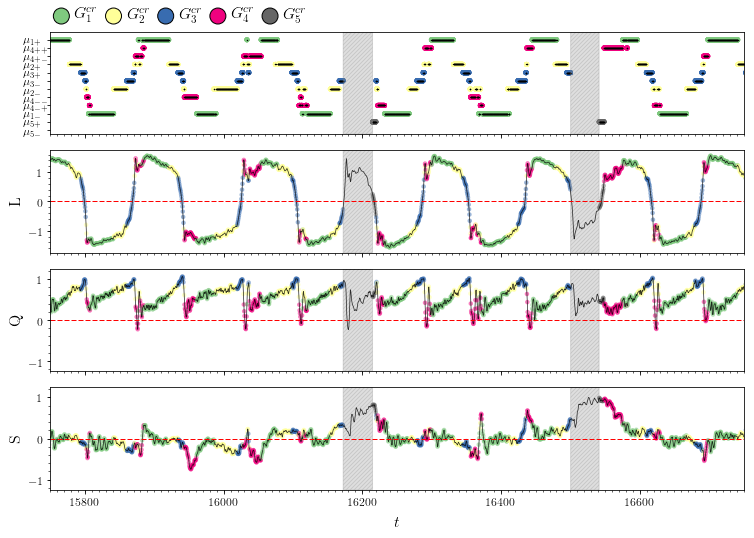

In [23]:
import matplotlib.transforms as mtransforms
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

## Cluster name and colors must be matched manually - must redo every time we run k-means
cluster = kmeans_sym_pr3.predict(pod_pr3[['k1','k2','k3','k4','k5','k6']])
index1=np.array([2.5,4,3,3,0,4,0,2.5,6,4,6,4])
index2=np.array(['$c_{2+}^{cr}$','$c_{4--}^{cr}$','$c_{3-}^{cr}$','$c_{3+}^{cr}$','$c_{1+}^{cr}$','$c_{4+-}^{cr}$','$c_{1-}^{cr}$','$c_{2-}^{cr}$','$c_{0-}^{cr}$','$c_{4++}^{cr}$','$c_{0+}^{cr}$','$c_{4-+}^{cr}$'])
index2=np.array([9              ,               5,              7,              8,             12,              10,              3,              6,              1,             11,             2,            4])
pod_pr3['cluster_color']=index1[cluster]
pod_pr3['cluster_number']=index2[cluster]
pod_pr3_cr = pod_pr3.loc[pod_pr3.CRregime==True]

plt.rcParams['figure.figsize'] = (10.5,7.5)
f, axes = plt.subplots(4,1, sharex=True, sharey=False)
ax= np.ravel(axes)

s=20
alpha=0.5
step=10

## Plot the cluster visited at time t
pod_pr3_cr.iloc[::, :].plot(kind='scatter', x='t', y='cluster_number', c='cluster_color', lw = 0.5, legend=False, ax=ax[0], s=20, alpha=1.0, colormap=cmap2, norm=norm, colorbar=False, marker='o', rasterized=True);
pod_pr3_cr.iloc[::, :].plot(kind='scatter', x='t', y='cluster_number', c='k', lw = 0.5, legend=False, ax=ax[0], s=2, alpha=0.5, colormap=cmap2, norm=norm, colorbar=False, marker='.', rasterized=True);

## Plot the amplitudes of modes L, Q, and S
i=1
for k in ['k1','k2','k4']:
    # Plot the time series
    pod_pr3.iloc[::step, :].plot(x='t', y=k,  lw=0.75, c='k', alpha=0.8, legend=False, xlim=[8100,10100], ylim=[-1.25,1.25], ax=ax[i], rasterized=True);

    # Color using the clusters
    pod_pr3_cr.head(1000000).iloc[::step, :].plot(kind='scatter', x='t', y=k, c='cluster_color', s=s, lw = 0.0, colormap=cmap2, norm=norm, ax=ax[i], xlim=[15750,16750],colorbar=False, alpha=alpha, rasterized=True);

    # Add line for y=0
    ax[i].axhline(y=0,color='red',linewidth=1.0, linestyle='--', dashes=(5, 2), rasterized=True)
    
    # and minor ticks
    majorLocator_y = MultipleLocator(1.0)
    minorLocator_y = MultipleLocator(0.2)
    ax[i].yaxis.set_major_locator(majorLocator_y)
    ax[i].yaxis.set_minor_locator(minorLocator_y)
    i= i+1 

    
## Cosmetics
## Shade areas inside the EC subset 
labels = ['','$\mathrm{L}$','$\mathrm{Q}$','$\mathrm{S}$']
for i in range(0,4):
    trans = mtransforms.blended_transform_factory(ax[i].transData, ax[i].transAxes)
    ax[i].fill_between(pod_pr3.t, 0, 1, where=pod_pr3.CRregime == False, color='gray',facecolor='gray', hatch = '//////', alpha=0.25, transform=trans, rasterized=True)
    ax[i].set_ylabel(labels[i])

    
## Add tics and labels    
ax[1].set_ylim([-1.75,1.75])
majorLocator_x = MultipleLocator(200)
minorLocator_x = MultipleLocator(10)
ax[3].xaxis.set_major_locator(majorLocator_x)
ax[3].xaxis.set_minor_locator(minorLocator_x)
ax[3].set_xlabel('$t$')


## Add caption with coloured circles at the top of the figure
from matplotlib.patches import Circle
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, DrawingArea, HPacker
labels = ['$G_5^{cr}$','$G_1^{cr}$','$G_2^{cr}$','$G_3^{cr}$','$G_4^{cr}$']

box0 = TextArea(labels[0], textprops=dict(size=16, color="k"))
box1 = TextArea(labels[1], textprops=dict(size=16, color="k"))
box2 = TextArea(labels[2], textprops=dict(size=16, color="k"))
box3 = TextArea(labels[3], textprops=dict(size=16, color="k"))
box4 = TextArea(labels[4], textprops=dict(size=16, color="k"))

p0 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(6.0))))
p1 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(0.0))))
p2 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(2.5))))
p3 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(3.0))))
p4 = Circle((8, 8), 8, ec="k", fc=mpl.colors.rgb2hex(cmap2(norm(4.0))))

cox0 = DrawingArea(12, 12, 0, 0); cox0.add_artist(p0)
cox1 = DrawingArea(12, 12, 0, 0); cox1.add_artist(p1)
cox2 = DrawingArea(12, 12, 0, 0); cox2.add_artist(p2)
cox3 = DrawingArea(12, 12, 0, 0); cox3.add_artist(p3)
cox4 = DrawingArea(12, 12, 0, 0); cox4.add_artist(p4)

box = HPacker(children=[cox1, box1, cox2, box2, cox3, box3, cox4, box4, cox0, box0],
              align="center",
              pad=3, sep=9)

anchored_box = AnchoredOffsetbox(loc=3,
                                 child=box, pad=0.,
                                 frameon=False,
                                 bbox_to_anchor=(0., 1.02),
                                 bbox_transform=ax[0].transAxes,
                                 borderpad=0.,
                                 )

ax[0].add_artist(anchored_box)


## Add labels for the cluster centroids
ax[0].set_ylim(0.5,13.0)
ax[0].set_yticks(range(1,13))
ax[0].set_yticklabels(['$\\mu_{5-}$','$\\mu_{5+}$','$\\mu_{1-}$','$\\mu_{4-+}$','$\\mu_{4--}$','$\\mu_{2-}$','$\\mu_{3-}$','$\\mu_{3+}$','$\\mu_{2+}$','$\\mu_{4+-}$','$\\mu_{4++}$','$\\mu_{1+}$'])

for label in ax[0].yaxis.get_majorticklabels():
    label.set_horizontalalignment('left')
    label.set_x(-0.03)

plt.tight_layout(pad=0.5) 
plt.savefig('figures_for_article/figure14.pdf',dpi=300)

### 2.6 Reversal dynamics in the phase-space diagrams and the generic reversal cycle (figure 15)

In [24]:
import pickle
filename_pr3 = './results_from_generic_reversal/generic_cycle_pr3.sav'
cycle_pr3  = pickle.load(open(filename_pr3, 'rb'))

In [25]:
step = 10
cluster = kmeans_sym_pr3.predict(alpha_cr_pr3.T)
#labels_pr3 = ['$\mu_1^{-}$','$\mu_4^{--}$','$\mu_4^{-+}$','$\mu_2^{-}$','$\mu_3^{-}$','$\mu_0^{-}$','$\mu_0^{+}$', '$\mu_3^{+}$', '$\mu_2^{+}$','$\mu_4^{+-}$','$\mu_4^{++}$', '$\mu_1^{+}$']
index=np.array([2.5,4,3,3,0,4,0,2.5,6,4,6,4])

Alpha_cr_pr3= pd.DataFrame(alpha_cr_pr3.T, columns=['k1','k2','k3','k4','k5','k6'])
Alpha_cr_pr3['cluster_color'] = index[cluster]

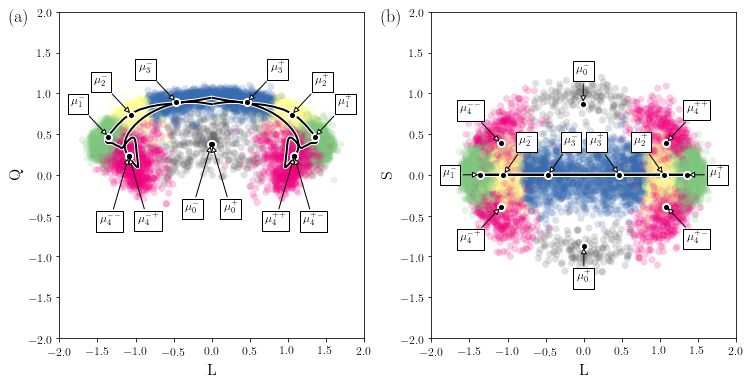

In [26]:
plt.rcParams['figure.figsize'] = (10.5,5.5)
bbox_props = dict(boxstyle="square,pad=0.3", fc="white", ec="k", lw=1)

nsamples=15000
alpha=0.20
s=50

# Colors are selected by hand here
#ax1 = f.add_axes([0.9, 0.7, 0.05, 0.1])
norm = mpl.colors.Normalize(vmin=0, vmax=6)
#cb1 = mpl.colorbar.ColorbarBase(ax1, cmap=cmap2, norm=norm, orientation='vertical')
#index=np.array([2.5,4,3,3,0,4,0,2.5,6,4,6,4])
#Alpha_cr_pr3= pd.DataFrame(alpha_cr_pr3.T, columns=['k1','k2','k3','k4','k5','k6'])
#Alpha_cr_pr3['cluster_cr'] = index[cluster]

labels_pr3 = ['$\mu_1^{-}$','$\mu_4^{--}$','$\mu_4^{-+}$','$\mu_2^{-}$','$\mu_3^{-}$','$\mu_0^{-}$','$\mu_0^{+}$', '$\mu_3^{+}$', '$\mu_2^{+}$','$\mu_4^{++}$','$\mu_4^{+-}$', '$\mu_1^{+}$']
offtagsx = np.zeros((n_clusters,5))
offtagsy = np.zeros((n_clusters,5))

# Offsets for the labels are also set by hand as to improve the visibility 
# For plot No. 1
offtagsx[0:5,0] = -0.4 ; offtagsx[7:12,0] = 0.4
offtagsy[0:5,0] = 0.4  ; offtagsy[7:12,0] = 0.4
offtagsy[1:3,0] = -0.8 ; offtagsy[9:11,0] = -0.8
offtagsx[1,0] = -0.25  ; offtagsx[9,0] = -0.25
offtagsx[2,0] = 0.25   ; offtagsx[10,0] = 0.25
offtagsy[5:7,0] = -0.8 ; offtagsx[5,0] = -0.25 ; offtagsx[6,0] = 0.25

# For plot No. 2
offtagsy[3:9,1] = 0.4
offtagsx[0:3,1] = -0.4 ; offtagsx[9:12,1] = 0.4
offtagsx[3:5,1] = 0.3 ; offtagsx[7:9,1] = -0.3
offtagsy[5,1] = 0.4 ; offtagsy[6,1] = -0.4
offtagsy[1,1] = 0.4 ; offtagsy[2,1] = -0.4
offtagsy[9,1] = 0.4 ; offtagsy[10,1] = -0.4

# For plot No. 3
offtagsx[0,2] = -0.25 ; offtagsx[11,2] = 0.25
offtagsx[1:6,2] = 0.5 ; offtagsx[6:11,2] = -0.5
offtagsx[3,2] = -0.6 ; offtagsx[8,2] = 0.6
offtagsx[1,2] = -0.25 ; offtagsx[2,2] = 0.25 
offtagsx[9,2] = -0.25 ; offtagsx[10,2] = 0.25 

offtagsy[4:6,2] = -0.5 ; offtagsy[6:8,2] = 0.5
offtagsy[0,2] = 0.5 ; offtagsy[11,2] = -0.5
offtagsy[3,2] = -0.1 ; offtagsy[8,2] = 0.1
offtagsy[1:3,2] = -0.75 ; offtagsy[9:11,2] = 0.75

# For plot No. 4
offtagsx[0:6,3] = -0.5 ; offtagsx[6:12,3] = 0.5 ;
offtagsx[1,3] = -0.5 ; offtagsx[2,3] = 0.5 ; 
offtagsx[9,3] = -0.5 ; 

offtagsx[3:5,3] = -0.25 ; offtagsx[7:9,3] = 0.25 ; 
offtagsy[0:12,3] = 0.5 ; offtagsy[5:7,3] = 0 ; 
offtagsy[1,3] = -0.5 ; offtagsy[10,3] = -0.5 ;
offtagsy[4,3] = -0.5 ; offtagsy[7,3] = -0.5 ; 

# For plot No. 5
offtagsx[0,4] = 0.25; offtagsx[11,4] = 0.5
offtagsx[3:5,4] = 0.25; offtagsx[7:9,4] = 0.5
offtagsx[5,4] = -0.15; offtagsx[6,4] = 0.15;
offtagsx[1,4] = -0.75 ; offtagsx[2,4] = -0.5
offtagsx[9,4] = -0.75 ; offtagsx[10,4] = -0.5

offtagsy[0,4] = 0.4; offtagsy[11,4] = 0.4
offtagsy[3:5,4] = 0.25; offtagsy[7:9,4] = 0.25
offtagsy[5:7,4] = 0.5;
offtagsy[1:3,4] = -0.75; offtagsy[9:11,4] = -0.5;

f, axes = plt.subplots(1,2, sharex=False, sharey=False)
ax= np.ravel(axes)

i=0
indexx = [0,0,0,3,1]
indexy = [1,3,2,5,4]
coordx = ['k1','k1'] # ['k1','k1','k1','k4','k2']
coordy = ['k2','k4','k3','k6','k5']
labelx = ['$\mathrm{L}$','$\mathrm{L}$','$\mathrm{L}$','$\mathrm{S}$','$\mathrm{Q}$']
labely = ['$\mathrm{Q}$','$\mathrm{S}$','$\mathrm{L}^*$','$\mathrm{S}^*$','$\mathrm{Q}^*$']


labels = range(0,2)
for k in coordx:
    ## Plot the datapoints coloured by cluster 
    Alpha_cr_pr3.sample(nsamples).plot(kind='scatter', x=coordx[i], y=coordy[i], c='cluster_color', s=s, lw = 0.0, colormap=cmap2, norm=norm, ax=ax[i],colorbar=False, alpha=alpha, rasterized=True);
    
    ## Plot the modal coefficients during a generic reversal
    ax[i].plot(cycle_pr3[coordx[i]+'mean'][:400],cycle_pr3[coordy[i]+'mean'][:400],linewidth=4, color='w', rasterized=True)
    ax[i].plot(cycle_pr3[coordx[i]+'mean'][401:],cycle_pr3[coordy[i]+'mean'][401:],linewidth=4, color='w', rasterized=True)
    ax[i].plot(cycle_pr3[coordx[i]+'mean'][:400],cycle_pr3[coordy[i]+'mean'][:400],linewidth=2, color='k', rasterized=True)
    ax[i].plot(cycle_pr3[coordx[i]+'mean'][401:],cycle_pr3[coordy[i]+'mean'][401:],linewidth=2, color='k', rasterized=True)
    
    ## Plot the cluster centroids and the labels
    x1 = centroids_pr3[:,indexx[i]]
    y1 = centroids_pr3[:,indexy[i]]    
    
    ax[i].plot(x1,y1,'ow',markersize=8)
    ax[i].plot(x1,y1,'ok',markersize=4)
    for j, txt in enumerate(labels_pr3):    
        ax[i].annotate(txt, xy=(x1[j],y1[j]), size=12, xytext=(x1[j]+offtagsx[j,i], y1[j]+offtagsy[j,i]), va="center", ha="center", arrowprops=dict(arrowstyle="-|>", facecolor='white'),bbox=bbox_props)

    ## Cosmetics
    ax[i].set_xlabel(labelx[i])
    ax[i].set_ylabel(labely[i])    
    ax[i].set_xlim([-2.0,2.0])
    ax[i].set_ylim([-2.0,2.0])
        
    i=i+1
    
ax[0].annotate('(a)', xy=(0,1), xycoords='axes fraction', xytext=(-50,-10), textcoords='offset points', fontsize=18)    
ax[1].annotate('(b)', xy=(0,1), xycoords='axes fraction', xytext=(-50,-10), textcoords='offset points', fontsize=18)    

    
plt.tight_layout(pad=0.75) 
plt.savefig('figures_for_article/figure15.pdf',dpi=300)

### 2.7 Last, we compute the conditional averages for table 5a

In [27]:
glb_pr3['cluster_color']=pod_pr3['cluster_color']
conditional_averages = glb_pr3.loc[glb_pr3.CRregime==True].groupby('cluster_color').mean()/glb_pr3.mean()

pd.set_option('precision', 2)


conditional_averages['prob']=glb_pr3.loc[glb_pr3.CRregime==True].groupby('cluster_color').t.count()/glb_pr3.loc[glb_pr3.CRregime==True].count().t*100

print(conditional_averages[['prob','f','ekin','apot']].to_latex())

\begin{tabular}{lrrrr}
\toprule
{} &   prob &     f &  ekin &  apot \\
cluster\_color &        &       &       &       \\
\midrule
0.0           &  43.53 &  1.49 &  1.15 &  0.96 \\
2.5           &  26.04 &  0.99 &  0.95 &  1.04 \\
3.0           &  13.63 &  0.36 &  0.76 &  1.09 \\
4.0           &  14.46 &  1.00 &  1.06 &  0.91 \\
6.0           &   2.35 &  0.36 &  0.82 &  1.06 \\
\bottomrule
\end{tabular}

